# День 2 — Продуктовые и финансовые метрики

## Цель

Цель этого ноутбука — посчитать ключевые продуктовые и финансовые метрики e-commerce на основе очищенной order-level витрины, подготовленной в День 1.

В этом ноутбуке анализируются:

* активность заказов и клиентов;
* GMV и динамика стоимости заказов;
* AOV;
* динамика оценок клиентов;
* товарные категории;
* платёжное поведение;
* ABC-анализ категорий.

## Методологическое примечание

В этом проекте GMV определяется как стоимость товаров без доставки:

`GMV = product_revenue`

Доставка анализируется отдельно как часть экономики заказа и клиентского опыта.

Это решение важно, потому что стоимость доставки — это не то же самое, что товарный оборот. В датасете нет комиссии маркетплейса, маржи, себестоимости и рекламных расходов, поэтому GMV в проекте нужно воспринимать как proxy-метрику, а не как настоящую выручку бизнеса.


In [1]:
# 1. Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2. Настройки отображения
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
# 3. Загрузка данных
orders_base = pd.read_csv(
    "../data/processed/orders_base.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

orders_base.shape

(99441, 33)

## 1. Проверка загруженной витрины

Перед расчётом продуктовых и финансовых метрик проверим, что загруженная витрина содержит одну строку на заказ и необходимые поля для анализа: статус заказа, даты, GMV, стоимость доставки, оплату, отзывы и флаги наличия связанных данных.

Это нужно, чтобы убедиться, что дальнейшие метрики считаются на корректном уровне детализации — `order_id`.


In [4]:
orders_base.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'items_count', 'products_count', 'sellers_count',
       'product_revenue', 'freight_value', 'payment_value',
       'payment_installments', 'payment_types_count', 'payment_records_count',
       'review_score', 'review_records_count', 'first_review_creation_date',
       'last_review_answer_timestamp', 'gmv', 'order_value_with_freight',
       'delivery_days', 'delivery_delay_days', 'is_delivered', 'has_review',
       'has_payment', 'has_items'],
      dtype='str')

In [5]:
orders_base["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders_base["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

In [7]:
orders_base.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'items_count', 'products_count', 'sellers_count',
       'product_revenue', 'freight_value', 'payment_value',
       'payment_installments', 'payment_types_count', 'payment_records_count',
       'review_score', 'review_records_count', 'first_review_creation_date',
       'last_review_answer_timestamp', 'gmv', 'order_value_with_freight',
       'delivery_days', 'delivery_delay_days', 'is_delivered', 'has_review',
       'has_payment', 'has_items'],
      dtype='str')

## 2. Выбор валидных заказов для расчёта KPI

Для основных продуктовых и финансовых метрик в этом ноутбуке используются только заказы со статусом `delivered`.

Это решение связано с тем, что доставленные заказы лучше всего отражают завершённые покупки: по ним можно корректно анализировать GMV, AOV, клиентские оценки, доставку и платёжное поведение.

Остальные статусы не удаляются из анализа полностью. Они используются отдельно для оценки качества операционного процесса: доли отменённых, недоступных, ещё не доставленных или находящихся в обработке заказов.


In [8]:
all_orders = orders_base.copy()
delivered_orders = orders_base[orders_base["order_status"] == "delivered"].copy()

all_orders.shape, delivered_orders.shape

((99441, 33), (96478, 33))

In [9]:
delivered_share = delivered_orders.shape[0] / all_orders.shape[0] * 100
canceled_share = (all_orders["order_status"] == "canceled").mean() * 100
unavailable_share = (all_orders["order_status"] == "unavailable").mean() * 100

status_summary = pd.DataFrame({
    "metric": [
        "all_orders",
        "delivered_orders",
        "delivered_share_pct",
        "canceled_share_pct",
        "unavailable_share_pct"
    ],
    "value": [
        all_orders.shape[0],
        delivered_orders.shape[0],
        delivered_share,
        canceled_share,
        unavailable_share
    ]
})

status_summary

,metric,value
0,all_orders,"99,441.00"
1,delivered_orders,"96,478.00"
2,delivered_share_pct,97.02
3,canceled_share_pct,0.63
4,unavailable_share_pct,0.61


### Вывод по статусам заказов

В датасете 99 441 заказ, из них 96 478 заказов имеют статус `delivered`, то есть около 97% всех заказов.

Для расчёта основных продуктовых и финансовых KPI дальше используются только доставленные заказы, потому что они отражают завершённые покупки. Заказы со статусами `canceled`, `unavailable`, `shipped`, `processing` и другими не включаются в основные метрики GMV и AOV, чтобы не смешивать завершённые и незавершённые транзакции.

При этом доли отменённых и недоступных заказов остаются важными операционными показателями: отменённые заказы составляют около 0.63%, а недоступные — около 0.61% всех заказов.


## 3. Основные продуктовые и финансовые KPI

На этом шаге рассчитываются базовые показатели e-commerce:

* количество доставленных заказов;
* количество уникальных клиентов;
* GMV;
* выручка от товаров;
* стоимость доставки;
* AOV;
* средний review score;
* среднее количество товаров в заказе;
* доля повторных клиентов.

Эти метрики дают общий снимок масштаба маркетплейса, покупательской активности, среднего чека и качества клиентского опыта.


In [10]:
total_orders = delivered_orders["order_id"].nunique()
total_customers = delivered_orders["customer_unique_id"].nunique()

gmv = delivered_orders["gmv"].sum()
product_revenue = delivered_orders["product_revenue"].sum()
freight_revenue = delivered_orders["freight_value"].sum()

aov = gmv / total_orders
avg_review_score = delivered_orders["review_score"].mean()
avg_items_per_order = delivered_orders["items_count"].mean()

customer_orders = (
    delivered_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customers_share = (customer_orders > 1).mean() * 100

kpi_summary = pd.DataFrame({
    "metric": [
        "delivered_orders",
        "unique_customers",
        "gmv",
        "product_revenue",
        "freight_revenue",
        "aov",
        "avg_review_score",
        "avg_items_per_order",
        "repeat_customers_share_pct"
    ],
    "value": [
        total_orders,
        total_customers,
        gmv,
        product_revenue,
        freight_revenue,
        aov,
        avg_review_score,
        avg_items_per_order,
        repeat_customers_share
    ]
})

kpi_summary

,metric,value
0,delivered_orders,"96,478.00"
1,unique_customers,"93,358.00"
2,gmv,"13,221,498.11"
3,product_revenue,"13,221,498.11"
4,freight_revenue,"2,198,275.64"
5,aov,137.04
6,avg_review_score,4.16
7,avg_items_per_order,1.14
8,repeat_customers_share_pct,3.00


### Вывод по основным KPI

В анализируемой выборке 96 478 доставленных заказов и 93 358 уникальных покупателей. Это подтверждает, что основная часть покупок в датасете — разовые: доля клиентов с повторными заказами составляет около 3%.

GMV, определённый как стоимость товаров без доставки, составляет 13.22 млн. Дополнительно маркетплейс сгенерировал 2.20 млн стоимости доставки, которую важно анализировать отдельно от товарного оборота.

Средний чек по доставленным заказам составляет около 137. Средняя оценка клиентов — 4.16 из 5, что говорит о достаточно высоком общем уровне клиентского опыта.

Среднее количество товарных строк в заказе — 1.14. Это означает, что большинство заказов содержат один товар, поэтому дальнейший анализ категорий и среднего чека нужно проводить аккуратно: один заказ чаще всего связан с одной основной покупкой.


## 4. Динамика метрик по месяцам

После расчёта общих KPI важно посмотреть, как метрики менялись во времени.

Месячная динамика помогает понять:

* рос ли маркетплейс по количеству заказов и GMV;
* менялся ли средний чек;
* ухудшалось или улучшалось качество клиентского опыта;
* есть ли заметные просадки, всплески или сезонность.


In [11]:
delivered_orders["order_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_metrics = (
    delivered_orders
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        gmv=("gmv", "sum"),
        freight_revenue=("freight_value", "sum"),
        aov=("gmv", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

monthly_metrics.head()

,order_month,orders,customers,gmv,freight_revenue,aov,avg_review_score
0,2016-09-01,1,1,134.97,8.49,134.97,1.00
1,2016-10-01,265,262,"40,325.11","6,165.55",152.17,4.01
2,2016-12-01,1,1,10.90,8.72,10.90,5.00
3,2017-01-01,750,718,"111,798.36","15,684.01",149.06,4.20
4,2017-02-01,1653,1630,"234,223.40","37,015.92",141.70,4.20


In [12]:
monthly_metrics.head()
monthly_metrics.tail()

,order_month,orders,customers,gmv,freight_revenue,aov,avg_review_score
18,2018-04-01,6798,6744,"973,534.09","159,344.84",143.21,4.21
19,2018-05-01,6749,6693,"977,544.69","151,229.83",144.84,4.24
20,2018-06-01,6099,6061,"856,077.86","155,900.43",140.36,4.31
21,2018-07-01,6159,6100,"867,953.46","159,853.82",140.92,4.32
22,2018-08-01,6351,6310,"838,576.64","146,915.00",132.04,4.31


In [13]:
date_range_summary = pd.DataFrame({
    "metric": [
        "min_order_purchase_timestamp",
        "max_order_purchase_timestamp",
        "first_month",
        "last_month"
    ],
    "value": [
        delivered_orders["order_purchase_timestamp"].min(),
        delivered_orders["order_purchase_timestamp"].max(),
        delivered_orders["order_purchase_timestamp"].min().to_period("M"),
        delivered_orders["order_purchase_timestamp"].max().to_period("M")
    ]
})

date_range_summary

,metric,value
0,min_order_purchase_timestamp,2016-09-15 12:16:38
1,max_order_purchase_timestamp,2018-08-29 15:00:37
2,first_month,2016-09
3,last_month,2018-08


In [14]:
monthly_metrics

,order_month,orders,customers,gmv,freight_revenue,aov,avg_review_score
0,2016-09-01,1,1,134.97,8.49,134.97,1.00
1,2016-10-01,265,262,"40,325.11","6,165.55",152.17,4.01
2,2016-12-01,1,1,10.90,8.72,10.90,5.00
3,2017-01-01,750,718,"111,798.36","15,684.01",149.06,4.20
4,2017-02-01,1653,1630,"234,223.40","37,015.92",141.70,4.20
5,2017-03-01,2546,2508,"359,198.85","55,132.10",141.08,4.19
6,2017-04-01,2303,2274,"340,669.68","50,142.72",147.92,4.14
7,2017-05-01,3546,3479,"489,338.25","77,513.15",138.00,4.24
8,2017-06-01,3135,3076,"421,923.37","68,127.00",134.58,4.22
9,2017-07-01,3872,3802,"481,604.52","84,694.56",124.38,4.26


### Методологическое решение по периоду анализа

Формально заказы в датасете начинаются 15 сентября 2016 года и заканчиваются 29 августа 2018 года.

Однако месяцы 2016 года выглядят неполными и нерегулярными: в сентябре и декабре есть только по одному доставленному заказу, а ноябрь отсутствует в выборке доставленных заказов. Поэтому для анализа месячной динамики основной период ограничен интервалом с января 2017 года по август 2018 года.

Август 2018 года также является неполным месяцем, так как данные заканчиваются 29 августа, поэтому выводы по нему нужно интерпретировать осторожно.


In [15]:
monthly_metrics_filtered = monthly_metrics[
    monthly_metrics["order_month"].between("2017-01-01", "2018-08-01")
].copy()

monthly_metrics_filtered

,order_month,orders,customers,gmv,freight_revenue,aov,avg_review_score
3,2017-01-01,750,718,"111,798.36","15,684.01",149.06,4.20
4,2017-02-01,1653,1630,"234,223.40","37,015.92",141.70,4.20
5,2017-03-01,2546,2508,"359,198.85","55,132.10",141.08,4.19
6,2017-04-01,2303,2274,"340,669.68","50,142.72",147.92,4.14
7,2017-05-01,3546,3479,"489,338.25","77,513.15",138.00,4.24
8,2017-06-01,3135,3076,"421,923.37","68,127.00",134.58,4.22
9,2017-07-01,3872,3802,"481,604.52","84,694.56",124.38,4.26
10,2017-08-01,4193,4114,"554,699.70","91,132.66",132.29,4.31
11,2017-09-01,4150,4083,"607,399.67","93,677.82",146.36,4.27
12,2017-10-01,4478,4417,"648,247.65","102,869.36",144.76,4.21


### Динамика заказов и GMV

Сначала посмотрим на две базовые метрики масштаба бизнеса:

* количество доставленных заказов по месяцам;
* GMV по месяцам.

Это позволит понять, рос ли маркетплейс во времени и были ли заметные всплески или просадки активности.


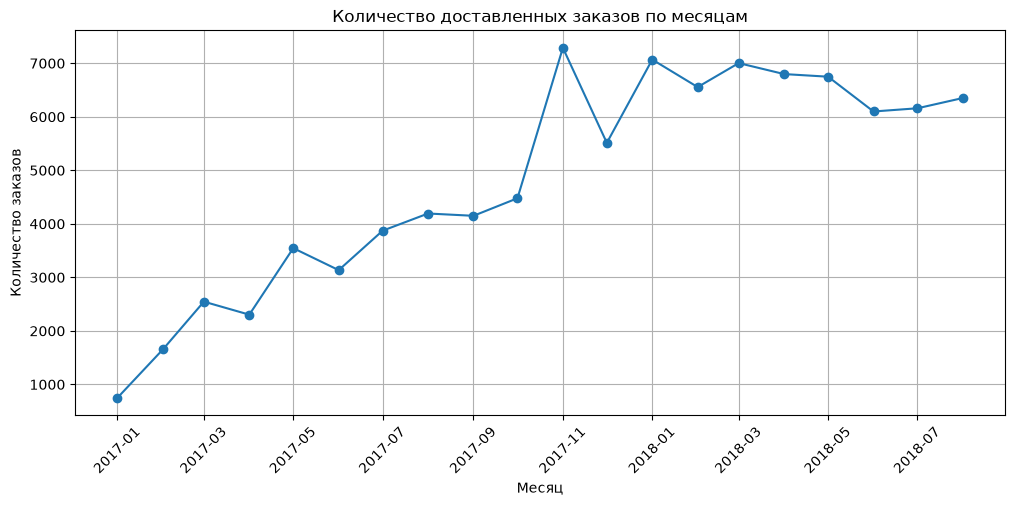

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics_filtered["order_month"],
    monthly_metrics_filtered["orders"],
    marker="o"
)

plt.title("Количество доставленных заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

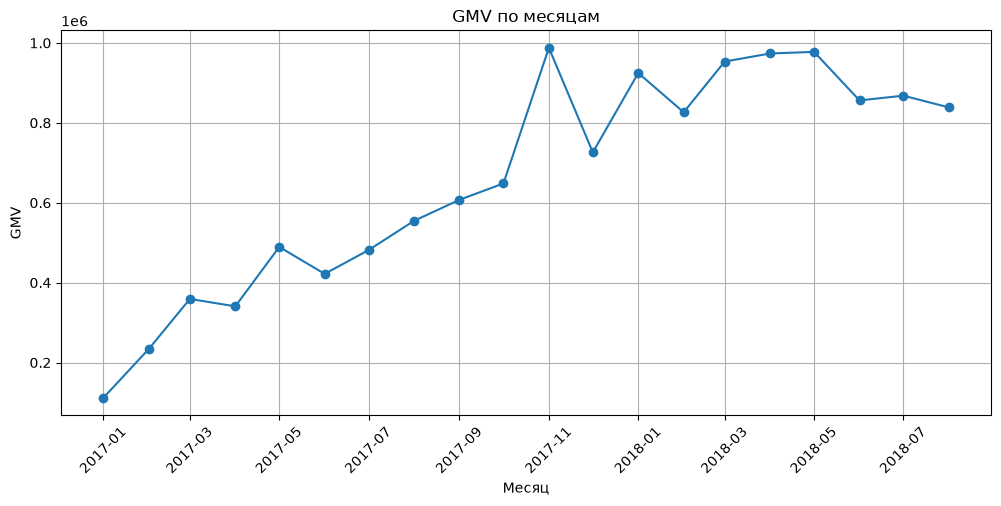

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics_filtered["order_month"],
    monthly_metrics_filtered["gmv"],
    marker="o"
)

plt.title("GMV по месяцам")
plt.xlabel("Месяц")
plt.ylabel("GMV")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Вывод по динамике заказов и GMV

С января 2017 года по конец 2017 года маркетплейс заметно вырос как по количеству доставленных заказов, так и по GMV. Количество заказов увеличилось с 750 в январе 2017 года до 7 289 в ноябре 2017 года, а GMV — со 111.8 тыс. до 987.8 тыс.

Ноябрь 2017 года является явным пиковым месяцем по объёму заказов и GMV. Это может быть связано с сезонным спросом или промо-периодом, однако в данных нет информации о маркетинговых кампаниях, поэтому это нельзя утверждать напрямую.

В 2018 году объём заказов и GMV остаются на высоком уровне. Период с января по май 2018 года выглядит как фаза стабилизации после роста 2017 года. В июне–августе 2018 года наблюдается умеренное снижение GMV относительно апреля–мая, но август 2018 года является неполным месяцем, поэтому его нужно интерпретировать осторожно.

В целом динамика показывает переход от фазы активного роста в 2017 году к более зрелому и стабильному уровню продаж в 2018 году.


### Динамика AOV и среднего review score

После анализа масштаба бизнеса важно проверить качество роста.

Для этого посмотрим:

- как менялся средний чек заказа;
- как менялась средняя оценка клиентов.

Это помогает понять, рос ли маркетплейс только за счёт количества заказов или также менялась структура покупок и качество клиентского опыта.

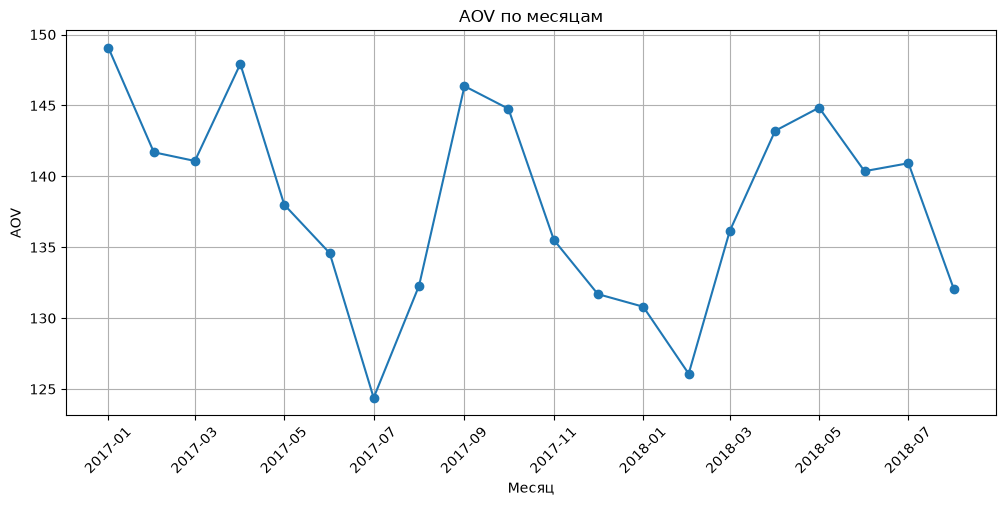

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics_filtered["order_month"],
    monthly_metrics_filtered["aov"],
    marker="o"
)

plt.title("AOV по месяцам")
plt.xlabel("Месяц")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

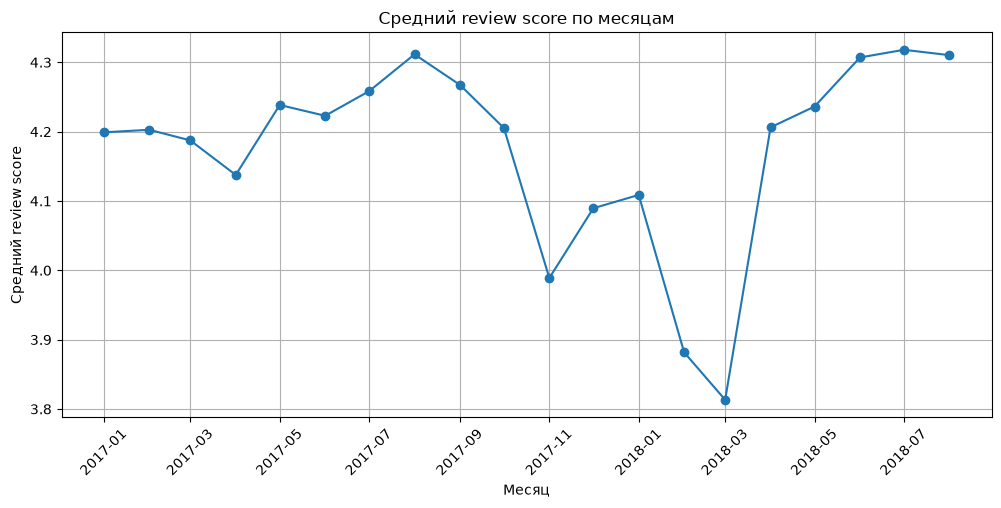

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics_filtered["order_month"],
    monthly_metrics_filtered["avg_review_score"],
    marker="o"
)

plt.title("Средний review score по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средний review score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Вывод по AOV и review score

AOV не показывает устойчивого восходящего тренда. Средний чек колеблется примерно в диапазоне от 124 до 149. Это означает, что рост GMV в 2017–2018 годах, скорее всего, был связан прежде всего с ростом количества заказов, а не с системным увеличением среднего чека.

В 2017 году AOV был волатильным: после высоких значений в начале года он снижался летом, затем снова вырос в сентябре–октябре. В начале 2018 года средний чек был ниже, но в апреле–мае снова поднялся до уровня около 143–145.

Средний review score большую часть периода находится выше 4.1, что говорит о достаточно хорошем общем клиентском опыте. Однако в ноябре 2017 — марте 2018 заметно ухудшение оценок, особенно в феврале и марте 2018 года, где средний review score опускается ниже 3.9.

Это важный сигнал: период высокого объёма заказов мог сопровождаться ухудшением клиентского опыта. Но по этим графикам нельзя утверждать причинно-следственную связь. На следующих этапах проекта это можно проверить через доставку, задержки, категории товаров и ML-модель риска плохого отзыва.

In [20]:
monthly_extremes = pd.DataFrame({
    "metric": [
        "max_aov_month",
        "max_aov",
        "min_aov_month",
        "min_aov",
        "max_review_score_month",
        "max_review_score",
        "min_review_score_month",
        "min_review_score"
    ],
    "value": [
        monthly_metrics_filtered.loc[monthly_metrics_filtered["aov"].idxmax(), "order_month"],
        monthly_metrics_filtered["aov"].max(),
        monthly_metrics_filtered.loc[monthly_metrics_filtered["aov"].idxmin(), "order_month"],
        monthly_metrics_filtered["aov"].min(),
        monthly_metrics_filtered.loc[monthly_metrics_filtered["avg_review_score"].idxmax(), "order_month"],
        monthly_metrics_filtered["avg_review_score"].max(),
        monthly_metrics_filtered.loc[monthly_metrics_filtered["avg_review_score"].idxmin(), "order_month"],
        monthly_metrics_filtered["avg_review_score"].min()
    ]
})

monthly_extremes

,metric,value
0,max_aov_month,2017-01-01 00:00:00
1,max_aov,149.06
2,min_aov_month,2017-07-01 00:00:00
3,min_aov,124.38
4,max_review_score_month,2018-07-01 00:00:00
5,max_review_score,4.32
6,min_review_score_month,2018-03-01 00:00:00
7,min_review_score,3.81


### Числовое подтверждение динамики AOV и review score

Максимальный AOV наблюдается в январе 2017 года — 149.06, минимальный AOV — в июле 2017 года, 124.38. Это подтверждает, что средний чек был волатильным и не имел устойчивого восходящего тренда.

Максимальный средний review score наблюдается в июле 2018 года — 4.32, минимальный — в марте 2018 года, 3.81. Снижение оценок в начале 2018 года является важным сигналом для дальнейшего анализа клиентского опыта, особенно в связке с доставкой, категориями товаров и будущей ML-моделью плохого отзыва.

## 5. Анализ товарных категорий

Для анализа категорий используется item-level таблица `order_items`, связанная с товарами через `product_id`.

Важно не соединять item-level данные с платежами напрямую, чтобы не задвоить выручку. В этом блоке GMV по категориям считается как сумма `price` из `order_items`, а стоимость доставки — как сумма `freight_value` из `order_items`.

Дальше анализируются только товары из доставленных заказов.

In [21]:
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

order_items.shape, products.shape, category_translation.shape

((112650, 7), (32951, 9), (71, 2))

In [22]:
category_items = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

category_items.shape

(112650, 9)

In [23]:
category_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [24]:
category_items = category_items[
    category_items["order_id"].isin(delivered_orders["order_id"])
].copy()

category_items.shape

(110197, 9)

In [25]:
category_missing_summary = pd.DataFrame({
    "column": [
        "product_category_name",
        "product_category_name_english"
    ],
    "missing_count": [
        category_items["product_category_name"].isna().sum(),
        category_items["product_category_name_english"].isna().sum()
    ],
    "missing_share_pct": [
        category_items["product_category_name"].isna().mean() * 100,
        category_items["product_category_name_english"].isna().mean() * 100
    ]
})

category_missing_summary

,column,missing_count,missing_share_pct
0,product_category_name,1537,1.39
1,product_category_name_english,1559,1.41


### Обработка пропусков в категориях

После соединения `order_items` с таблицами товаров и переводов около 1.4% товарных строк не имеют категории или английского названия категории.

Эти строки не удаляются, потому что удаление привело бы к потере части GMV. Вместо этого отсутствующие категории помечаются как `unknown`.

Такой подход сохраняет полноту финансового анализа и одновременно явно фиксирует ограничение качества данных.

In [26]:
category_items["category"] = (
    category_items["product_category_name_english"]
    .fillna("unknown")
)

category_items[["product_category_name", "product_category_name_english", "category"]].isna().sum()

product_category_name            1537
product_category_name_english    1559
category                            0
dtype: int64

In [27]:
category_metrics = (
    category_items
    .groupby("category")
    .agg(
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        products=("product_id", "nunique"),
        sellers=("seller_id", "nunique"),
        gmv=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
        avg_item_price=("price", "mean"),
        avg_freight_value=("freight_value", "mean")
    )
    .reset_index()
)

category_metrics["aov_proxy"] = category_metrics["gmv"] / category_metrics["orders"]
category_metrics["freight_to_gmv_pct"] = (
    category_metrics["freight_revenue"] / category_metrics["gmv"] * 100
)

category_metrics.sort_values("gmv", ascending=False).head(10)

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct
43,health_beauty,8647,9465,2397,479,"1,233,131.72","178,957.81",130.28,18.91,142.61,14.51
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72
65,sports_leisure,7530,8431,2822,466,"954,852.55","163,404.36",113.25,19.38,126.81,17.11
15,computers_accessories,6530,7644,1600,279,"888,724.61","143,999.16",116.26,18.84,136.10,16.20
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65
49,housewares,5743,6795,2282,452,"615,628.69","142,763.56",90.60,21.01,107.20,23.19
20,cool_stuff,3559,3718,770,259,"610,204.10","81,476.79",164.12,21.91,171.45,13.35
5,auto,3810,4140,1853,371,"578,966.65","90,488.10",139.85,21.86,151.96,15.63
69,toys,3804,4030,1373,242,"471,286.48","75,774.58",116.94,18.80,123.89,16.08


### Вывод по топ-категориям по GMV

Основной GMV формируется несколькими крупными категориями. Лидируют `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`.

Категория `health_beauty` занимает первое место по GMV — около 1.23 млн. При этом у неё высокий объём заказов и достаточно большое количество продавцов, что делает её одной из ключевых категорий маркетплейса.

`watches_gifts` находится на втором месте по GMV, хотя заказов у неё меньше, чем у `health_beauty` и `bed_bath_table`. Это связано с более высоким средним item price и высоким `aov_proxy`.

`bed_bath_table` — одна из крупнейших категорий по количеству заказов и товарных строк, но её средняя цена ниже. Это пример категории, которая даёт GMV скорее за счёт объёма, чем за счёт высокого среднего чека.

Категории `furniture_decor` и `housewares` имеют высокую долю доставки относительно GMV — около 23–24%. Это может быть связано с габаритами товаров и важно для анализа customer experience: высокая стоимость доставки может влиять на восприятие заказа клиентом.

In [28]:
category_order_reviews = (
    category_items[["order_id", "category"]]
    .drop_duplicates()
    .merge(
        delivered_orders[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

category_review_metrics = (
    category_order_reviews
    .groupby("category")
    .agg(
        reviewed_orders=("review_score", "count"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

category_metrics = category_metrics.merge(
    category_review_metrics,
    on="category",
    how="left"
)

category_metrics.sort_values("gmv", ascending=False).head(10)

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score
43,health_beauty,8647,9465,2397,479,"1,233,131.72","178,957.81",130.28,18.91,142.61,14.51,8601,4.23
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42,5454,4.12
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72,9177,4.00
65,sports_leisure,7530,8431,2822,466,"954,852.55","163,404.36",113.25,19.38,126.81,17.11,7486,4.23
15,computers_accessories,6530,7644,1600,279,"888,724.61","143,999.16",116.26,18.84,136.10,16.20,6499,4.08
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65,6260,4.06
49,housewares,5743,6795,2282,452,"615,628.69","142,763.56",90.60,21.01,107.20,23.19,5709,4.19
20,cool_stuff,3559,3718,770,259,"610,204.10","81,476.79",164.12,21.91,171.45,13.35,3531,4.22
5,auto,3810,4140,1853,371,"578,966.65","90,488.10",139.85,21.86,151.96,15.63,3792,4.15
69,toys,3804,4030,1373,242,"471,286.48","75,774.58",116.94,18.80,123.89,16.08,3774,4.24


### Вывод по категориям с учётом review score

Топ-категории по GMV отличаются не только объёмом продаж, но и качеством клиентского опыта.

`health_beauty` и `sports_leisure` выглядят сильными категориями: они входят в топ по GMV и при этом имеют высокий средний review score — около 4.23.

`watches_gifts` показывает высокий GMV при меньшем количестве заказов, что связано с более высоким средним чеком категории.

`bed_bath_table` является одной из крупнейших категорий по количеству заказов и GMV, но имеет более низкий средний review score — около 4.00. Это может указывать на проблемы с качеством клиентского опыта, доставкой, ожиданиями клиентов или характеристиками товаров.

`furniture_decor` и `housewares` имеют высокую долю доставки относительно GMV. Для таких категорий стоимость и качество доставки могут быть особенно важными факторами клиентского опыта.

Важно: review score находится на уровне заказа, а не отдельного товара. Поэтому оценка категории считается через пары `order_id + category`, чтобы не завышать вес заказов с несколькими товарными строками.

### Рейтинги категорий

Для более детального анализа посмотрим категории в нескольких разрезах:

- топ категорий по GMV;
- топ категорий по количеству заказов;
- топ категорий по `aov_proxy`;
- категории с низким средним review score;
- категории с высокой долей доставки относительно GMV.

Для метрик качества и среднего чека будем использовать минимальный порог по количеству заказов, чтобы не делать выводы по слишком маленьким категориям.

In [29]:
min_orders_threshold = 500

top_categories_by_gmv = (
    category_metrics
    .sort_values("gmv", ascending=False)
    .head(10)
)

top_categories_by_orders = (
    category_metrics
    .sort_values("orders", ascending=False)
    .head(10)
)

top_categories_by_aov = (
    category_metrics[category_metrics["orders"] >= min_orders_threshold]
    .sort_values("aov_proxy", ascending=False)
    .head(10)
)

low_review_categories = (
    category_metrics[category_metrics["reviewed_orders"] >= min_orders_threshold]
    .sort_values("avg_review_score", ascending=True)
    .head(10)
)

high_freight_categories = (
    category_metrics[category_metrics["orders"] >= min_orders_threshold]
    .sort_values("freight_to_gmv_pct", ascending=False)
    .head(10)
)

In [30]:
top_categories_by_orders

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72,9177,4.00
43,health_beauty,8647,9465,2397,479,"1,233,131.72","178,957.81",130.28,18.91,142.61,14.51,8601,4.23
65,sports_leisure,7530,8431,2822,466,"954,852.55","163,404.36",113.25,19.38,126.81,17.11,7486,4.23
15,computers_accessories,6530,7644,1600,279,"888,724.61","143,999.16",116.26,18.84,136.10,16.20,6499,4.08
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65,6260,4.06
49,housewares,5743,6795,2282,452,"615,628.69","142,763.56",90.60,21.01,107.20,23.19,5709,4.19
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42,5454,4.12
68,telephony,4093,4430,1112,142,"309,860.23","69,342.39",69.95,15.65,75.70,22.38,4069,4.05
5,auto,3810,4140,1853,371,"578,966.65","90,488.10",139.85,21.86,151.96,15.63,3792,4.15
69,toys,3804,4030,1373,242,"471,286.48","75,774.58",116.94,18.80,123.89,16.08,3774,4.24


In [31]:
top_categories_by_aov

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score
56,musical_instruments,611,651,279,67,"184,315.74","17,871.38",283.13,27.45,301.66,9.70,605,4.23
63,small_appliances,609,658,220,97,"182,754.12","15,354.35",277.74,23.33,300.09,8.40,604,4.26
57,office_furniture,1254,1668,302,30,"268,154.31","67,057.05",160.76,40.20,213.84,25.01,1244,3.64
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42,5454,4.12
17,construction_tools_construction,736,916,393,123,"142,108.49","20,273.52",155.14,22.13,193.08,14.27,731,4.13
20,cool_stuff,3559,3718,770,259,"610,204.10","81,476.79",164.12,21.91,171.45,13.35,3531,4.22
5,auto,3810,4140,1853,371,"578,966.65","90,488.10",139.85,21.86,151.96,15.63,3792,4.15
16,consoles_games,1018,1089,300,81,"148,003.37","19,094.36",135.91,17.53,145.39,12.90,1009,4.18
43,health_beauty,8647,9465,2397,479,"1,233,131.72","178,957.81",130.28,18.91,142.61,14.51,8601,4.23
6,baby,2809,2982,890,240,"400,421.84","66,305.81",134.28,22.24,142.55,16.56,2787,4.10


In [32]:
low_review_categories

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score
57,office_furniture,1254,1668,302,30,"268,154.31","67,057.05",160.76,40.20,213.84,25.01,1244,3.64
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72,9177,4.00
70,unknown,1412,1559,595,253,"175,967.21","27,386.63",112.87,17.57,124.62,15.56,1402,4.00
68,telephony,4093,4430,1112,142,"309,860.23","69,342.39",69.95,15.65,75.70,22.38,4069,4.05
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65,6260,4.06
15,computers_accessories,6530,7644,1600,279,"888,724.61","143,999.16",116.26,18.84,136.10,16.20,6499,4.08
6,baby,2809,2982,890,240,"400,421.84","66,305.81",134.28,22.24,142.55,16.56,2787,4.10
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42,5454,4.12
26,electronics,2517,2729,507,145,"155,043.93","45,679.16",56.81,16.74,61.60,29.46,2498,4.12
17,construction_tools_construction,736,916,393,123,"142,108.49","20,273.52",155.14,22.13,193.08,14.27,731,4.13


In [33]:
high_freight_categories

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score
26,electronics,2517,2729,507,145,"155,043.93","45,679.16",56.81,16.74,61.60,29.46,2498,4.12
57,office_furniture,1254,1668,302,30,"268,154.31","67,057.05",160.76,40.20,213.84,25.01,1244,3.64
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65,6260,4.06
49,housewares,5743,6795,2282,452,"615,628.69","142,763.56",90.60,21.01,107.20,23.19,5709,4.19
68,telephony,4093,4430,1112,142,"309,860.23","69,342.39",69.95,15.65,75.70,22.38,4069,4.05
53,luggage_accessories,1019,1077,346,73,"138,701.63","30,076.49",128.79,27.93,136.12,21.68,1015,4.37
42,garden_tools,3448,4268,725,227,"470,495.28","96,650.40",110.24,22.65,136.45,20.54,3428,4.18
28,fashion_bags_accessories,1820,1985,829,97,"149,329.39","30,558.90",75.23,15.39,82.05,20.46,1811,4.24
66,stationery,2264,2466,831,172,"223,788.69","45,786.36",90.75,18.57,98.85,20.46,2251,4.29
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72,9177,4.00


### Вывод по рейтингам категорий

Категории отличаются не только объёмом продаж, но и экономикой заказа, стоимостью доставки и качеством клиентского опыта.

По количеству заказов лидирует `bed_bath_table` — 9 272 заказа. Также в топ по заказам входят `health_beauty`, `sports_leisure`, `computers_accessories`, `furniture_decor`, `housewares` и `watches_gifts`. Это основные массовые категории маркетплейса.

По `aov_proxy` лидируют `musical_instruments` и `small_appliances`: у них меньше заказов, чем у крупнейших категорий, но выше средняя стоимость заказа внутри категории. `watches_gifts` также выглядит сильной категорией: она сочетает высокий GMV, высокий `aov_proxy` и крупный объём заказов.

Самый проблемный сигнал виден у `office_furniture`: категория имеет высокий `aov_proxy` — около 214, высокую долю доставки к GMV — около 25%, и самый низкий средний review score среди крупных категорий — 3.64. Это может указывать на проблемы с доставкой, ожиданиями клиентов, качеством товаров или операционной сложностью категории.

`bed_bath_table` — крупнейшая категория по количеству заказов, но её средний review score около 4.00, ниже многих других крупных категорий. Это важная категория для дополнительного анализа, потому что даже небольшое ухудшение клиентского опыта в массовой категории может влиять на большое число покупателей.

Категории `electronics`, `office_furniture`, `furniture_decor`, `housewares` и `telephony` имеют высокую долю доставки относительно GMV. Это может быть связано с низкой стоимостью товаров, габаритами, логистикой или структурой заказов. Такие категории важно анализировать не только по GMV, но и по влиянию доставки на клиентский опыт.

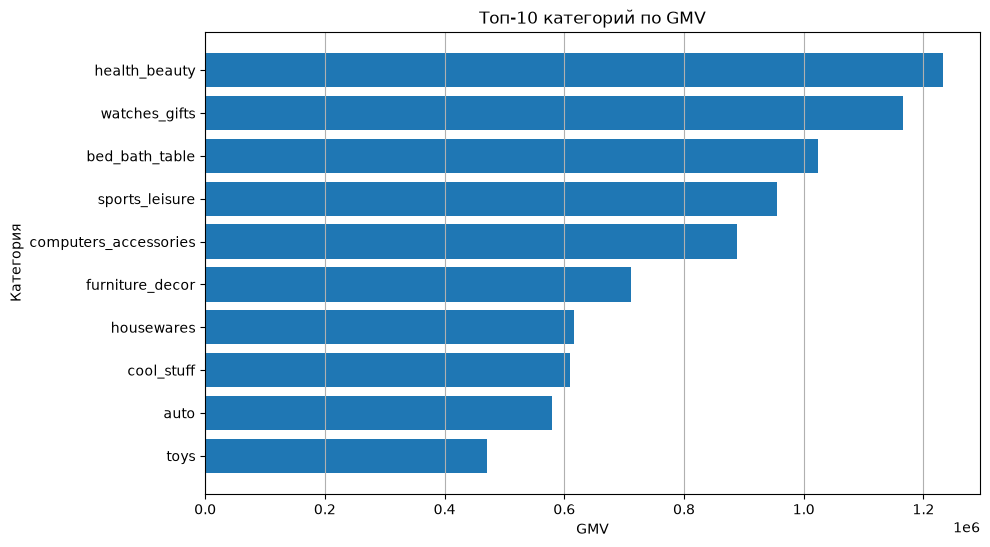

In [34]:
plt.figure(figsize=(10, 6))

top_categories_by_gmv_plot = top_categories_by_gmv.sort_values("gmv", ascending=True)

plt.barh(
    top_categories_by_gmv_plot["category"],
    top_categories_by_gmv_plot["gmv"]
)

plt.title("Топ-10 категорий по GMV")
plt.xlabel("GMV")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

## 6. ABC-анализ категорий

ABC-анализ позволяет разделить категории по их вкладу в общий GMV.

Логика анализа:

- категории A — формируют основную часть GMV;
- категории B — дают средний вклад;
- категории C — длинный хвост ассортимента.

В этом проекте используется классический подход:

- A: категории до 80% накопленного GMV;
- B: категории от 80% до 95% накопленного GMV;
- C: категории после 95% накопленного GMV.

Такой анализ помогает понять, какие категории критичны для удержания товарного оборота, а какие относятся к длинному хвосту ассортимента.

In [35]:
abc_categories = (
    category_metrics
    .sort_values("gmv", ascending=False)
    .copy()
)

abc_categories["gmv_share_pct"] = (
    abc_categories["gmv"] / abc_categories["gmv"].sum() * 100
)

abc_categories["cumulative_gmv_share_pct"] = (
    abc_categories["gmv_share_pct"].cumsum()
)

def assign_abc_segment(cumulative_share):
    if cumulative_share <= 80:
        return "A"
    elif cumulative_share <= 95:
        return "B"
    else:
        return "C"

abc_categories["abc_segment"] = abc_categories["cumulative_gmv_share_pct"].apply(assign_abc_segment)

abc_categories.head(20)

,category,orders,items,products,sellers,gmv,freight_revenue,avg_item_price,avg_freight_value,aov_proxy,freight_to_gmv_pct,reviewed_orders,avg_review_score,gmv_share_pct,cumulative_gmv_share_pct,abc_segment
43,health_beauty,8647,9465,2397,479,"1,233,131.72","178,957.81",130.28,18.91,142.61,14.51,8601,4.23,9.33,9.33,A
71,watches_gifts,5495,5859,1300,95,"1,166,176.98","98,156.14",199.04,16.75,212.23,8.42,5454,4.12,8.82,18.15,A
7,bed_bath_table,9272,10953,2991,189,"1,023,434.76","201,774.50",93.44,18.42,110.38,19.72,9177,4.00,7.74,25.89,A
65,sports_leisure,7530,8431,2822,466,"954,852.55","163,404.36",113.25,19.38,126.81,17.11,7486,4.23,7.22,33.11,A
15,computers_accessories,6530,7644,1600,279,"888,724.61","143,999.16",116.26,18.84,136.10,16.20,6499,4.08,6.72,39.83,A
39,furniture_decor,6307,8160,2593,352,"711,927.69","168,402.23",87.25,20.64,112.88,23.65,6260,4.06,5.38,45.22,A
49,housewares,5743,6795,2282,452,"615,628.69","142,763.56",90.60,21.01,107.20,23.19,5709,4.19,4.66,49.87,A
20,cool_stuff,3559,3718,770,259,"610,204.10","81,476.79",164.12,21.91,171.45,13.35,3531,4.22,4.62,54.49,A
5,auto,3810,4140,1853,371,"578,966.65","90,488.10",139.85,21.86,151.96,15.63,3792,4.15,4.38,58.87,A
69,toys,3804,4030,1373,242,"471,286.48","75,774.58",116.94,18.80,123.89,16.08,3774,4.24,3.56,62.43,A


In [36]:
abc_summary = (
    abc_categories
    .groupby("abc_segment")
    .agg(
        categories_count=("category", "nunique"),
        gmv=("gmv", "sum"),
        orders=("orders", "sum"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

abc_summary["gmv_share_pct"] = abc_summary["gmv"] / abc_summary["gmv"].sum() * 100
abc_summary["orders_share_pct"] = abc_summary["orders"] / abc_summary["orders"].sum() * 100

abc_summary

,abc_segment,categories_count,gmv,orders,avg_review_score,gmv_share_pct,orders_share_pct
0,A,17,"10,535,883.37",77828,4.13,79.69,80.01
1,B,16,"2,007,353.98",14082,4.14,15.18,14.48
2,C,39,"678,260.76",5366,4.17,5.13,5.52


### Вывод по ABC-анализу категорий

ABC-анализ показывает, что структура GMV маркетплейса концентрирована в ограниченном наборе категорий.

В A-сегмент вошли 17 категорий, которые формируют около 79.7% GMV и около 80.0% заказов. Это ключевые категории маркетплейса: их качество, доступность, логистика и ассортимент критичны для удержания основного объёма продаж.

B-сегмент включает 16 категорий, которые дают около 15.2% GMV. Эти категории можно рассматривать как потенциальные точки роста: они уже дают заметный вклад, но не входят в ядро оборота.

C-сегмент включает 39 категорий, но формирует только около 5.1% GMV. Это длинный хвост ассортимента. Такие категории могут быть полезны для широты предложения, но требуют отдельной проверки операционной эффективности.

Важно, что средний review score по ABC-сегментам отличается незначительно: A — 4.13, B — 4.14, C — 4.17. Это означает, что различие между сегментами связано прежде всего с объёмом GMV и заказов, а не с явной разницей в средней клиентской оценке.

Отдельно стоит отметить категорию `office_furniture`: она входит в A-сегмент, но имеет низкий средний review score и высокую долю доставки относительно GMV. Это пример категории, которая важна для оборота, но может создавать риски для клиентского опыта.

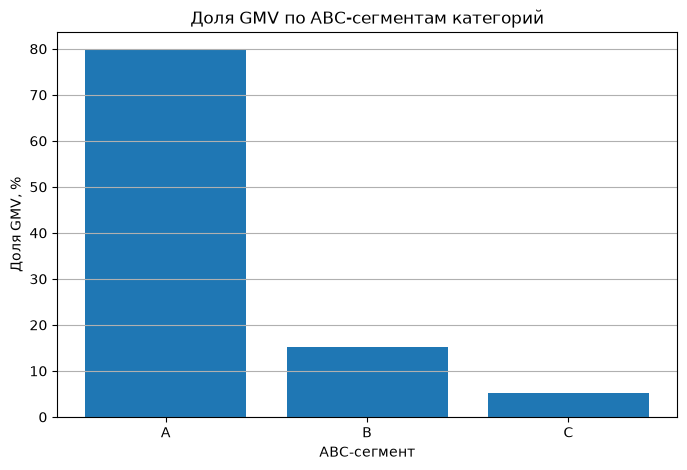

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    abc_summary["abc_segment"],
    abc_summary["gmv_share_pct"]
)

plt.title("Доля GMV по ABC-сегментам категорий")
plt.xlabel("ABC-сегмент")
plt.ylabel("Доля GMV, %")
plt.grid(axis="y")
plt.show()

### Вывод по ABC-сегментам

График подтверждает концентрацию GMV в A-сегменте: 17 ключевых категорий формируют около 80% товарного оборота.

B-сегмент даёт около 15% GMV и может рассматриваться как зона потенциального роста.

C-сегмент включает больше всего категорий, но суммарно формирует только около 5% GMV. Это длинный хвост ассортимента: он может быть важен для широты предложения, но его вклад в общий оборот ограничен.

## 7. Анализ платёжного поведения

В этом блоке анализируется платёжное поведение клиентов:

- какие способы оплаты используются чаще всего;
- какая сумма оплат проходит через разные payment types;
- сколько платежных записей приходится на заказ;
- как количество installments связано со средним чеком и review score.

Важно учитывать, что таблица `payments` имеет уровень детализации ниже заказа: у одного заказа может быть несколько платёжных записей. Поэтому при соединении с order-level витриной нужно контролировать риск задвоения заказов и GMV.

In [38]:
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

payments.shape

(103886, 5)

In [39]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [40]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [41]:
payments_delivered = payments[
    payments["order_id"].isin(delivered_orders["order_id"])
].copy()

payments_delivered.shape

(100756, 5)

In [42]:
payment_type_summary = (
    payments_delivered
    .groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean")
    )
    .reset_index()
    .sort_values("payment_value", ascending=False)
)

payment_type_summary["payment_records_share_pct"] = (
    payment_type_summary["payment_records"] / payment_type_summary["payment_records"].sum() * 100
)

payment_type_summary["payment_value_share_pct"] = (
    payment_type_summary["payment_value"] / payment_type_summary["payment_value"].sum() * 100
)

payment_type_summary["orders_share_pct_non_exclusive"] = (
    payment_type_summary["orders"] / delivered_orders["order_id"].nunique() * 100
)

payment_type_summary

,payment_type,payment_records,orders,payment_value,avg_payment_value,avg_installments,payment_records_share_pct,payment_value_share_pct,orders_share_pct_non_exclusive
1,credit_card,74586,74304,"12,101,094.88",162.24,3.50,74.03,78.46,77.02
0,boleto,19191,19191,"2,769,932.58",144.33,1.00,19.05,17.96,19.89
3,voucher,5493,3679,"343,013.19",62.45,1.00,5.45,2.22,3.81
2,debit_card,1486,1485,"208,421.12",140.26,1.00,1.47,1.35,1.54


### Вывод по способам оплаты

Основной способ оплаты в доставленных заказах — `credit_card`. На него приходится около 74% платёжных записей и около 78% общей суммы оплат. Это главный платёжный инструмент в датасете.

`boleto` занимает второе место: около 19% платёжных записей и около 18% суммы оплат. При этом для `boleto` среднее количество installments равно 1, что логично для этого типа оплаты.

`voucher` встречается заметно реже и даёт только около 2.2% суммы оплат. При этом количество заказов с voucher меньше количества voucher-записей, потому что в одном заказе может быть несколько voucher-платежей.

Важно: доля заказов по payment type является non-exclusive метрикой. Один заказ может иметь несколько способов оплаты, поэтому суммы долей по заказам не обязаны давать 100%.

In [43]:
payment_total_check = pd.DataFrame({
    "metric": [
        "payments_delivered_total",
        "delivered_orders_payment_value",
        "delivered_orders_order_value_with_freight",
        "delivered_orders_gmv",
        "difference_payments_vs_order_value_with_freight",
        "difference_payments_vs_gmv"
    ],
    "value": [
        payments_delivered["payment_value"].sum(),
        delivered_orders["payment_value"].sum(),
        delivered_orders["order_value_with_freight"].sum(),
        delivered_orders["gmv"].sum(),
        payments_delivered["payment_value"].sum() - delivered_orders["order_value_with_freight"].sum(),
        payments_delivered["payment_value"].sum() - delivered_orders["gmv"].sum()
    ]
})

payment_total_check

,metric,value
0,payments_delivered_total,"15,422,461.77"
1,delivered_orders_payment_value,"15,422,461.77"
2,delivered_orders_order_value_with_freight,"15,419,773.75"
3,delivered_orders_gmv,"13,221,498.11"
4,difference_payments_vs_order_value_with_freight,"2,688.02"
5,difference_payments_vs_gmv,"2,200,963.66"


### Проверка связи payment_value, GMV и стоимости доставки

Сумма `payment_value` по доставленным заказам почти совпадает с `order_value_with_freight`, то есть со стоимостью товаров вместе с доставкой.

Это подтверждает важное методологическое различие:

- `GMV` в проекте считается как стоимость товаров без доставки;
- `freight_value` анализируется отдельно;
- `payment_value` отражает сумму, которую клиент фактически оплатил, и поэтому ближе к `product_revenue + freight_value`.

Разница между суммой платежей и `order_value_with_freight` составляет около 2.7 тыс. на фоне 15.4 млн, поэтому её можно считать небольшой технической аномалией данных.

Для финансового анализа это означает, что `payment_value` нельзя напрямую называть GMV. GMV отражает товарный оборот, а `payment_value` — клиентскую оплату заказа с доставкой.

In [44]:
payment_order_level = (
    payments_delivered
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
        payment_records=("payment_sequential", "count"),
        payment_types_count=("payment_type", "nunique")
    )
    .reset_index()
)

payment_order_level.head()

,order_id,payment_value,max_installments,payment_records,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,1


In [45]:
installments_analysis = (
    delivered_orders[[
        "order_id",
        "gmv",
        "order_value_with_freight",
        "review_score"
    ]]
    .merge(
        payment_order_level,
        on="order_id",
        how="left"
    )
)

installments_analysis[[
    "gmv",
    "order_value_with_freight",
    "payment_value",
    "max_installments",
    "payment_records",
    "payment_types_count",
    "review_score"
]].describe()

,gmv,order_value_with_freight,payment_value,max_installments,payment_records,payment_types_count,review_score
count,"96,478.00","96,478.00","96,477.00","96,477.00","96,477.00","96,477.00","95,832.00"
mean,137.04,159.83,159.86,2.93,1.04,1.02,4.16
std,209.05,218.79,218.81,2.71,0.37,0.15,1.28
min,0.85,9.59,9.59,0.00,1.00,1.00,1.00
25%,45.90,61.85,61.88,1.00,1.00,1.00,4.00
50%,86.57,105.28,105.28,2.00,1.00,1.00,5.00
75%,149.90,176.26,176.33,4.00,1.00,1.00,5.00
max,"13,440.00","13,664.08","13,664.08",24.00,26.00,2.00,5.00


### Подготовка данных для анализа installments

Для анализа количества платежей в рассрочку используется order-level таблица платежей.

Так как в платежной таблице возможны несколько записей на один заказ, на уровне заказа рассчитываются:

- общая сумма оплаты;
- максимальное количество installments;
- количество платёжных записей;
- количество разных способов оплаты.

Для анализа installments исключаются редкие технические аномалии: заказы без платежной информации и заказы с `max_installments = 0`.

In [46]:
installments_analysis_clean = installments_analysis[
    installments_analysis["max_installments"].notna()
    & (installments_analysis["max_installments"] > 0)
].copy()

installments_analysis_clean.shape

(96475, 8)

In [47]:
installments_summary = (
    installments_analysis_clean
    .groupby("max_installments")
    .agg(
        orders=("order_id", "nunique"),
        avg_gmv=("gmv", "mean"),
        median_gmv=("gmv", "median"),
        avg_order_value_with_freight=("order_value_with_freight", "mean"),
        median_order_value_with_freight=("order_value_with_freight", "median"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

installments_summary["orders_share_pct"] = (
    installments_summary["orders"] / installments_summary["orders"].sum() * 100
)

installments_summary

,max_installments,orders,avg_gmv,median_gmv,avg_order_value_with_freight,median_order_value_with_freight,avg_review_score,orders_share_pct
0,1.00,46814,99.94,59.99,120.21,79.24,4.19,48.52
1,2.00,12026,107.77,89.99,128.38,111.41,4.17,12.47
2,3.00,10133,121.49,91.49,143.74,112.24,4.12,10.50
3,4.00,6864,141.25,99.00,164.70,117.48,4.12,7.11
4,5.00,5083,158.93,107.00,183.72,126.92,4.12,5.27
5,6.00,3792,183.11,119.90,210.24,139.03,4.14,3.93
6,7.00,1559,162.53,110.00,187.53,139.96,4.14,1.62
7,8.00,4120,279.03,189.00,308.22,212.44,4.09,4.27
8,9.00,618,171.83,89.90,198.61,105.47,4.19,0.64
9,10.00,5137,375.44,205.00,413.99,239.18,4.04,5.32


### Вывод по installments

Почти половина доставленных заказов оплачивается одним платежом: `1 installment` составляет около 48.5% заказов.

В целом видно, что при увеличении количества installments растёт средний чек. Это логично: более дорогие заказы клиенты чаще оплачивают в рассрочку или несколькими платежами.

Однако для больших значений installments количество заказов становится маленьким, поэтому интерпретировать каждое отдельное значение нестабильно. Для дальнейшего анализа лучше сгруппировать installments в укрупнённые интервалы.

In [48]:
def assign_installments_bucket(x):
    if x == 1:
        return "1"
    elif x <= 3:
        return "2-3"
    elif x <= 6:
        return "4-6"
    elif x <= 10:
        return "7-10"
    else:
        return "11+"

installments_analysis_clean["installments_bucket"] = (
    installments_analysis_clean["max_installments"]
    .apply(assign_installments_bucket)
)

installments_bucket_summary = (
    installments_analysis_clean
    .groupby("installments_bucket")
    .agg(
        orders=("order_id", "nunique"),
        avg_gmv=("gmv", "mean"),
        median_gmv=("gmv", "median"),
        avg_order_value_with_freight=("order_value_with_freight", "mean"),
        median_order_value_with_freight=("order_value_with_freight", "median"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

installments_bucket_summary["orders_share_pct"] = (
    installments_bucket_summary["orders"] / installments_bucket_summary["orders"].sum() * 100
)

bucket_order = ["1", "2-3", "4-6", "7-10", "11+"]
installments_bucket_summary["installments_bucket"] = pd.Categorical(
    installments_bucket_summary["installments_bucket"],
    categories=bucket_order,
    ordered=True
)

installments_bucket_summary = installments_bucket_summary.sort_values("installments_bucket")

installments_bucket_summary

,installments_bucket,orders,avg_gmv,median_gmv,avg_order_value_with_freight,median_order_value_with_freight,avg_review_score,orders_share_pct
0,1,46814,99.94,59.99,120.21,79.24,4.19,48.52
2,2-3,22159,114.05,90.00,135.41,111.82,4.15,22.97
3,4-6,15739,157.04,107.80,181.82,128.20,4.13,16.31
4,7-10,11434,300.67,179.50,333.36,206.07,4.08,11.85
1,11+,329,322.07,185.00,359.32,216.05,3.94,0.34


### Вывод по группам installments

`Installments` показывает, на сколько частей клиент разделил оплату заказа. Значение `1` означает оплату одним платежом, значения больше 1 — оплату в несколько частей.

Почти половина доставленных заказов оплачивается одним платежом — 48.5%. Ещё около 23% заказов оплачиваются в 2–3 платежа.

Видна заметная связь между количеством installments и средним чеком. Заказы с одним платежом имеют средний GMV около 100, тогда как заказы с 7–10 installments имеют средний GMV около 301. Это говорит о том, что рассрочка чаще используется для более дорогих заказов.

Средний review score при большем количестве installments немного ниже: от 4.19 для одного платежа до 4.08 для 7–10 installments и 3.94 для 11+ installments. Но группу 11+ нужно интерпретировать осторожно, потому что она составляет только 0.34% заказов.

Эта метрика может быть полезна для будущей ML-модели: количество installments может отражать финансовое поведение клиента и стоимость заказа.

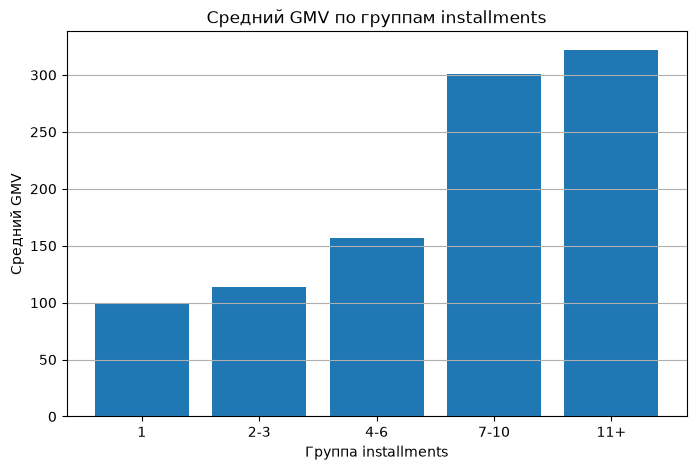

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    installments_bucket_summary["installments_bucket"].astype(str),
    installments_bucket_summary["avg_gmv"]
)

plt.title("Средний GMV по группам installments")
plt.xlabel("Группа installments")
plt.ylabel("Средний GMV")
plt.grid(axis="y")
plt.show()

### Вывод по связи installments и GMV

График показывает, что средний GMV растёт вместе с количеством installments. Заказы, оплаченные одним платежом, имеют средний GMV около 100, тогда как заказы с 7–10 installments имеют средний GMV около 301.

Это подтверждает гипотезу, что рассрочка чаще используется для более дорогих заказов.

Группу `11+` нужно интерпретировать осторожно: средний GMV в ней высокий, но сама группа очень маленькая — около 0.34% заказов.

### Итог по платёжному поведению

Платёжное поведение в датасете показывает, что основным способом оплаты является `credit_card`: на него приходится около 78% суммы оплат и около 77% доставленных заказов.

`payment_value` почти совпадает с `order_value_with_freight`, то есть с суммой стоимости товаров и доставки. Поэтому в проекте важно не смешивать эти понятия:

- `GMV` = стоимость товаров без доставки;
- `freight_value` = стоимость доставки;
- `payment_value` = фактическая сумма оплаты клиентом, близкая к `GMV + freight`.

Анализ installments показывает, что более дорогие заказы чаще оплачиваются в несколько частей. Заказы с одним платежом имеют средний GMV около 100, а заказы с 7–10 installments — около 301.

Также видно небольшое снижение среднего review score при росте количества installments, но это нельзя интерпретировать как причинно-следственную связь. Скорее всего, installments связаны с более дорогими и потенциально более сложными заказами.

Для будущей ML-модели количество installments, сумма оплаты, количество платёжных записей и количество способов оплаты могут быть полезными признаками клиентского поведения.

## 8. Финальные выводы Дня 2

В этом ноутбуке были рассчитаны ключевые продуктовые и финансовые метрики маркетплейса на основе order-level витрины, подготовленной в День 1.

Основные результаты:

1. В анализе использовались только доставленные заказы — 96 478 заказов, или около 97% всех заказов.
2. GMV, определённый как стоимость товаров без доставки, составил около 13.22 млн.
3. Стоимость доставки составила около 2.20 млн и анализировалась отдельно от GMV.
4. Средний чек по доставленным заказам составил около 137.
5. Средний review score составил около 4.16.
6. Доля повторных клиентов составила около 3%, что говорит о преобладании разовых покупок.
7. Рост GMV в 2017–2018 годах в основном был связан с ростом количества заказов, а не с устойчивым ростом AOV.
8. В начале 2018 года наблюдалось заметное снижение среднего review score, особенно в феврале–марте.
9. Основной GMV формируется ограниченным набором категорий: `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, `computers_accessories`.
10. ABC-анализ показал, что 17 категорий A-сегмента формируют около 80% GMV.
11. Категория `office_furniture` выглядит как важная, но рискованная категория: она входит в A-сегмент, имеет высокий средний чек, высокую долю доставки и самый низкий review score среди крупных категорий.
12. Основной способ оплаты — `credit_card`.
13. `payment_value` отражает сумму оплаты клиента с доставкой, поэтому его нельзя напрямую называть GMV.
14. Количество installments связано со средним чеком: более дорогие заказы чаще оплачиваются в несколько частей.

Главный аналитический вывод:

Маркетплейс имеет выраженную концентрацию GMV в ограниченном наборе категорий. При этом финансовая значимость категории не всегда совпадает с качеством клиентского опыта. Поэтому категории нужно анализировать не только по GMV и заказам, но и по review score, стоимости доставки и операционным рискам.